In [1]:
from sedona.spark import *
from pyspark.sql.functions import *
from pyspark.sql.utils import AnalysisException

config = SedonaContext.builder() \
    .getOrCreate()

sedona = SedonaContext.create(config)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Setting Spark log level to "WARN".
26/03/02 18:46:48 INFO core/src/lib.rs: Sedona native acceleration engine v0.12.0 ready
                                                                                

# Recommended runtime

## Tiny

# Cost: 

Cost of executing this over King County.

- **~$6**

Cost of executing this over Kirkland.

- **>$1**

# NDVI

Find average NDVI over 500m radius of the house.

## **NDVI** Formula

($\frac{\mathrm{NIR} - \mathrm{RED}}{\mathrm{NIR} + \mathrm{RED}}$)

### Bands used 
- RED   / B04
- NIR   / B08


Make sure to filter out the unnecessary rasters outside of King County.


```python
import wkls

_aoi = wkls.us.wa.kingcounty.wkt()
```

In [2]:
import wkls

_aoi = wkls.us.wa.kirkland.wkt()

# Small bounding box in central Kirkland (~0.5km²)
kirkland_small = "POLYGON((-122.212 47.676, -122.200 47.676, -122.200 47.682, -122.212 47.682, -122.212 47.676))"

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Read in the broze house sales dataset.

In [3]:
house_sales_df = (
    sedona.table(f"org_catalog.gde_bronze.king_co_homes")
            .where(f"ST_Intersects(geometry, ST_GeomFromWKT('{kirkland_small}'))")
            .withColumn("geometry_buffer", expr("ST_Buffer(geometry, 500, true)"))
)


house_sales_df.createOrReplaceTempView("house_sales")
house_sales_df.show()

[Stage 3:>                                                          (0 + 1) / 1]

+------+-----------+------------+----------+----------+--------+------------+-----------+---------+----------------+-----------------+----+--------+------+------------+-----------+--------+-------+----------+---------+--------+----+------+----------+-----+-----------+---------+-------+----+---------+---------+---------+---------+---------+----+----+---------+-------------+------------+-------------+-------------+----------------+------------+----------+-------------+-------------+---------------+----------+---------+--------------------+--------------------+
|   _c0|    sale_id|        pinx| sale_date|sale_price|sale_nbr|sale_warning|join_status|join_year|        latitude|        longitude|area|    city|zoning| subdivision|present_use|land_val|imp_val|year_built|year_reno|sqft_lot|sqft|sqft_1|sqft_fbsmt|grade|fbsmt_grade|condition|stories|beds|bath_full|bath_3qtr|bath_half|garb_sqft|gara_sqft|wfnt|golf|greenbelt|noise_traffic|view_rainier|view_olympics|view_cascades|view_territorial|vi

# Reading in the sentinel 2 dataset using the STAC API

In [4]:
from pyspark.sql.functions import col, explode, map_values

# Load from STAC datasource
df = (sedona.read.format("stac") 
    .option("itemsLimitMax", "1000") 
    .option("itemsLimitPerRequest", "200") 
    .load("https://earth-search.aws.element84.com/v1/collections/sentinel-2-c1-l2a")  # STAC Endpoint
    .where(f"ST_INTERSECTS(geometry, ST_GeomFromWKT('{kirkland_small}'))")                      # Apply Spatial Filter
    .withColumn("rast_nir", expr("assets.nir.rast"))                                  # Promote the NIR band
    .withColumn("rast_red", expr("assets.red.rast"))                                  # Promote the Red band
    .select("id",                                                                     #--------------------
            expr("date(datetime)"),                                                   #
            col("eo:cloud_cover").alias("cloud_cover"),                               #
            col("grid:code").alias("grid_code"),                                      #
            "geometry",                                                               # Select Attributes
            "rast_red",                                                               #
            "rast_nir",                                                               #
            "platform",                                                               #
            "constellation",                                                          #--------------------
           )
    .filter("cloud_cover <  10")                                                      #Apply the cloud cover filter
    .filter("DATE(datetime) between '2024-06-01' and'2024-07-31'")                    #Apply Date Range Filter
    .orderBy(expr("date(datetime)"))
    .repartition(1_000)
    .cache()
     )
df.createOrReplaceTempView("asset_items")
df.show()

[Stage 13:===================================>                (690 + 13) / 1000]

+--------------------+----------+-----------+----------+--------------------+--------------------+--------------------+-----------+-------------+
|                  id|  datetime|cloud_cover| grid_code|            geometry|            rast_red|            rast_nir|   platform|constellation|
+--------------------+----------+-----------+----------+--------------------+--------------------+--------------------+-----------+-------------+
|S2B_T10TET_202407...|2024-07-10|   0.002056|MGRS-10TET|POLYGON ((-122.79...|LazyLoadOutDbGrid...|LazyLoadOutDbGrid...|sentinel-2b|   sentinel-2|
|S2B_T10TET_202407...|2024-07-13|    3.79E-4|MGRS-10TET|POLYGON ((-123.00...|LazyLoadOutDbGrid...|LazyLoadOutDbGrid...|sentinel-2b|   sentinel-2|
|S2A_T10TET_202407...|2024-07-08|   0.001423|MGRS-10TET|POLYGON ((-123.00...|LazyLoadOutDbGrid...|LazyLoadOutDbGrid...|sentinel-2a|   sentinel-2|
|S2A_T10TET_202406...|2024-06-25|   0.002617|MGRS-10TET|POLYGON ((-122.80...|LazyLoadOutDbGrid...|LazyLoadOutDbGrid...|senti

,raster_image1
0,
1,
2,
3,
4,

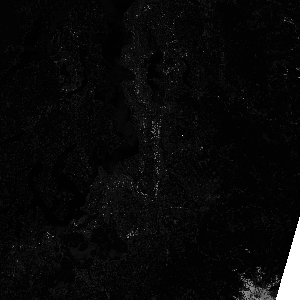
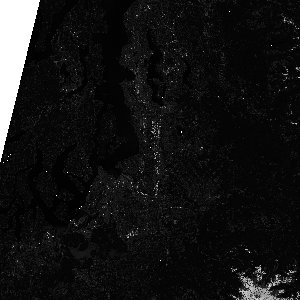
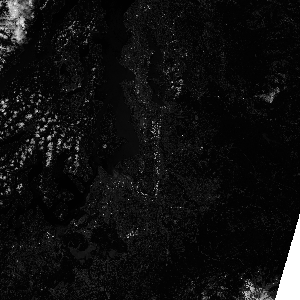
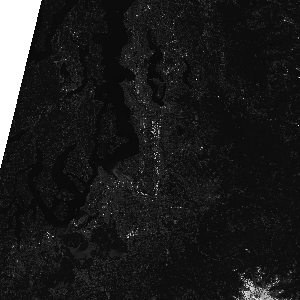
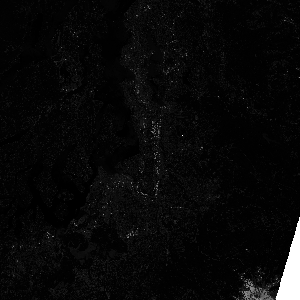

In [5]:
dfImage = df.limit(5) \
    .selectExpr("RS_AsImage(rast_red, 300) as raster_image1")

# Display the image
SedonaUtils.display_image(dfImage)

## Stacking the Red and NIR bands into one raster

In [6]:
tile_size = 512
stackTileExploded_df = sedona.sql(f'''
   with exp as ( SELECT *, 
        RS_StackTileExplode(Array(rast_red, 
                                  rast_nir
                                  ),
                            0, 
                            {tile_size}, {tile_size},
                            false)
    FROM asset_items
    )
    SELECT
        id,
        x,
        y,
        datetime,
        grid_code,
        tile as rast,
        RS_ENVELOPE(tile) as geometry,
        RS_NumBands(tile) as band_cnt
    FROM 
        exp
''')

stackTileExploded_df = stackTileExploded_df.repartition(1000)

from pyspark.storagelevel import StorageLevel
stackTileExploded_df = stackTileExploded_df.persist(StorageLevel.DISK_ONLY)
print("Count:", stackTileExploded_df.count())
stackTileExploded_df.createOrReplaceTempView("tiled_raster")

[Stage 28:====================================================>(991 + 3) / 1000]

Count: 4356


## Calculating NDVI index

In [7]:
ndvi_house = sedona.sql("""

WITH ndvi_raster AS (
SELECT
        a.geometry_buffer,
        a.sale_id,
        ndvi
FROM
    house_sales a
JOIN
    (SELECT
       geometry,
       datetime,
       RS_MapAlgebra(rast, 'D', 'out = (rast[1] > 0 && rast[0] > 0) ? (rast[1] - rast[0]) / (rast[1] + rast[0]) : null;') as ndvi
     FROM tiled_raster
     WHERE NOT isnan(RS_SummaryStats(rast,'max'))) b
ON
   ST_Intersects(b.geometry,ST_TRANSFORM(a.geometry_buffer,"EPSG:4269","EPSG:32610"))
),
zonal_stats (
SELECT
    RS_ZONALSTATS(ndvi,geometry_buffer,'mean') mean_ndvi,
    sale_id
FROM
    ndvi_raster
)

SELECT 
    AVG(mean_ndvi) AS mean_ndvi,
    sale_id
FROM
    zonal_stats
GROUP BY
    sale_id

""").cache() # Caching the result as I will be using the result more than once. When converting this into a job, please remove .cache(), .count(), and .show() below

ndvi_house.show()

[Stage 43:=============================================>      (869 + 12) / 1000]

+-------------------+-----------+
|          mean_ndvi|    sale_id|
+-------------------+-----------+
| 0.4256381828969361|2006..18601|
|0.29733447128850826|2020..11577|
|0.41544165875282985|2001..22659|
| 0.3419839722711446|2016..31724|
|0.29984422478018413|2005..15667|
| 0.4325098512909695| 2000..4651|
|0.41477983697203147|2013..39173|
|0.39395090464724797| 2012..1905|
| 0.3569458206180197|2013..36362|
|0.39174457350823594| 2001..4207|
| 0.4461519822398217| 2007..3020|
|0.24871895088872586|2007..39758|
|0.39395090464724797|2013..17730|
|  0.406309480112559|2013..19024|
|0.42678191174281976|2023..19087|
| 0.4017852371453985| 2015..5185|
|0.29546366277523123|2000..15935|
|0.38814459171115173| 2010..4762|
|0.31728084464082557|2021..43155|
| 0.4059334825398281|2017..14102|
+-------------------+-----------+
only showing top 20 rows


In [8]:
ndvi_house.createOrReplaceTempView("ndvi_house")

In [9]:
ndvi_house.count()

376

In [10]:
database = "gde_silver"

In [11]:
sedona.sql(f"CREATE DATABASE IF NOT EXISTS org_catalog.{database}").show()

++
||
++
++



In [12]:
sedona.sql("""

SELECT 
    a.*,
    b.mean_ndvi as mean_ndvi_500m_radius
FROM
    house_sales a
JOIN
    ndvi_house b
ON
    a.sale_id = b.sale_id

""").select("sale_id", "mean_ndvi_500m_radius").writeTo(f"org_catalog.{database}.house_sales_ndvi_silver").createOrReplace()

In [13]:
sedona.sql("SHOW TABLES IN org_catalog.gde_silver").show()

+----------+--------------------+-----------+
| namespace|           tableName|isTemporary|
+----------+--------------------+-----------+
|gde_silver|         census_data|      false|
|gde_silver|homes_distance_to...|      false|
|gde_silver|homes_distance_to...|      false|
|gde_silver| homes_flood_hazards|      false|
|gde_silver| homes_school_scores|      false|
|gde_silver|homes_seismic_haz...|      false|
|gde_silver|house_sales_ndvi_...|      false|
|gde_silver|     roads_proximity|      false|
|gde_silver|         school_data|      false|
+----------+--------------------+-----------+

